<a href="https://colab.research.google.com/github/Sak-shi437/linear_regression/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

- Topics Covered:
    1. Loading Dataset
    2. Implementing Various Operations


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

---
#### Loading Dataset

In [137]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head(2)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998


---
#### Implenting Various Operations

In [ ]:
df["Location"].unique()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.dtypes

---
#### Operation on Column: 'ID'

In [138]:
df.drop("Id",axis=1,inplace=True)

In [ ]:
df.head()

---
#### Operation on Column :Garage"

In [ ]:
df["Garage"].unique()

In [139]:
df["Garage"] = df["Garage"].map({
    "Yes":1,
    "No" : 0
})

In [ ]:
df.head()

---
#### Operation on Columns: "Location", "Condition"

In [140]:
# One-Hot Encode Location and Condition

df = pd.get_dummies(
    df,
    columns=["Location", "Condition"],
    drop_first=True
)

In [ ]:
df.head()

In [141]:
# Converting Datatype to int

df["Location_Rural"] = df["Location_Rural"].astype(int)
df["Location_Suburban"] = df["Location_Suburban"].astype(int)
df["Location_Urban"] = df["Location_Urban"].astype(int)
df["Condition_Fair"] = df["Condition_Fair"].astype(int)
df["Condition_Good"] = df["Condition_Good"].astype(int)
df["Condition_Poor"] = df["Condition_Poor"].astype(int)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,0,0,0,0,0,0
1,4272,5,4,3,1958,0,424998,0,0,0,0,0,0
2,3592,2,2,3,1938,0,266746,0,0,0,0,1,0
3,966,4,2,2,1902,1,244020,0,1,0,1,0,0
4,4926,1,4,2,1975,1,636056,0,0,0,1,0,0


---
#### Operation on Column: 'Price'

In [142]:
X = df.drop("Price", axis=1)
y = df["Price"]

---
#### Train Test Split

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

---
#### Standarization

- Process: Added then Removed
- Reason: Multi Linear Regression

- applying a formula for every row of features.
- Formula: z_score = (xi-u)std daviation, u=0, sd=1
- So that even for larger values on features, minimizing time to obtain global minima

- train: fit_transform, calculates z_score
- test: transform, calculates using "train" mean and sd

```
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

```

---
#### Simple Linear Regression

In [144]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

X_test
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

---
#### Predicting & Visualization

```
if (Standrization):
- `lr.predict(X_test.iloc[[0]])` Changed to `lr.predict(X_test[[0]])`
- Reason: "# Standarization": Changed df to Numpy Array, which don's support `iloc`

else:
```

In [145]:
lr.predict(X_test.iloc[[0]])
y_pred = lr.predict(X_test)

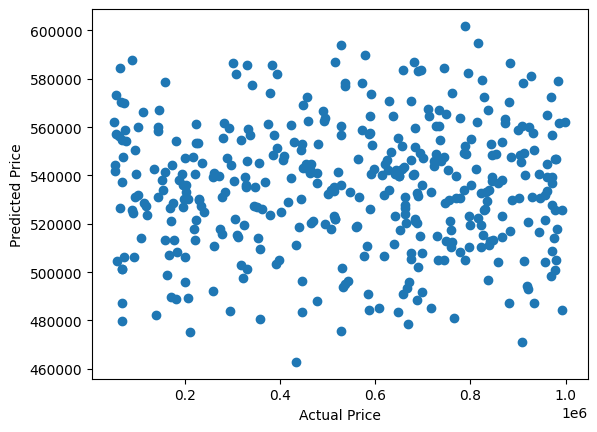

In [146]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [147]:
X = df[['Area']]
y = df['Price']

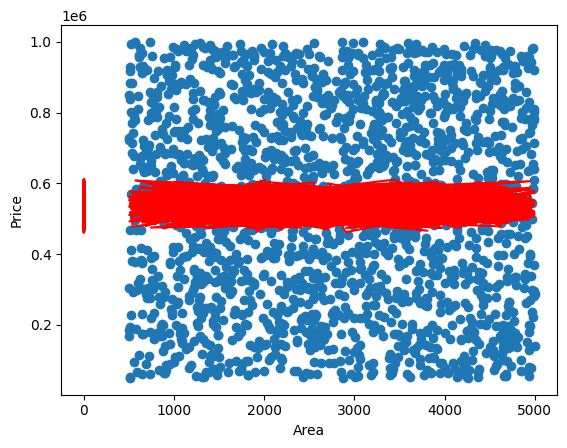

In [148]:
plt.scatter(df['Area'], df['Price'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [149]:
m = lr.coef_
b = lr.intercept_

m * 8.58 + b

array([278515.59115426, 279179.34493385, 195618.44127149, 482106.63069704,
       279529.65825319, 298885.42348997, 289825.04165203, 377293.40373392,
       169392.20685969, 485155.31244512, 167486.3664359 , 313469.17854483])

In [150]:
print("Train Score:", lr.score(X_train, y_train))
print("Test Score:", lr.score(X_test, y_test))

Train Score: 0.009856184863687889
Test Score: -0.006717808430749761


---
#### Performance Matrices

In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 243241.97758826384
RMSE: 279859.72583784326
R2: -0.006717808430749761


---